In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from facenet_pytorch import MTCNN
from pytorch_grad_cam import GradCAM
import os
from sklearn.metrics.pairwise import cosine_similarity
from utils import extract_frontal_face
from insightface.iresnet import iresnet50

/home/wiktor/Doktorat/SD/S2/ML_DL/mlndl-gradface/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(image_size=112, margin=20, thresholds=[0.2, 0.2, 0.2], device=device)
model = iresnet50()
checkpoint = torch.load("../insightface/backbone.pth", map_location=torch.device('cuda'))
model.load_state_dict(checkpoint)
model.eval()
model = model.cuda()

In [3]:
class SimilarityTarget:
    def __init__(self, ref_emb):
        self.ref_emb = ref_emb

    def __call__(self, model_output):
        return F.cosine_similarity(model_output, self.ref_emb)
target_layer = model.layer4
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [4]:
dataset_path = "/home/wiktor/Doktorat/repositories/mavceleb_baseline/dataset/mavceleb_v1_train/faces"
language = "English"

grad_list = []
score_list = []

for it in tqdm(range(10000)):
    identity_ids = os.listdir(dataset_path)
    while True:
        ids_pair = np.random.choice(identity_ids, 2)
        id_1 = ids_pair[0]
        id_2 = ids_pair[1]
        if id_1 != id_2:
            break
    try:
        folder_1 = np.random.choice(os.listdir(os.path.join(dataset_path, id_1, language)), 1)[0]
        file_1 = np.random.choice(os.listdir(os.path.join(dataset_path, id_1, language, folder_1)), 1)[0]
        face_1_path = os.path.join(dataset_path, id_1, language, folder_1, file_1)

        folder_2 = np.random.choice(os.listdir(os.path.join(dataset_path, id_2, language)), 1)[0]
        file_2 = np.random.choice(os.listdir(os.path.join(dataset_path, id_2, language, folder_2)), 1)[0]
        face_2_path = os.path.join(dataset_path, id_2, language, folder_2, file_2)

        img1_pil = Image.open(face_1_path).convert("RGB")
        img2_pil = Image.open(face_2_path).convert("RGB")

        img1 = extract_frontal_face(img1_pil, mtcnn)
        img2 = extract_frontal_face(img2_pil, mtcnn)
        img1 = img1.unsqueeze(0).to(device)
        img2 = img2.unsqueeze(0).to(device)
        with torch.no_grad():
            ref_embedding = model(img2)  # [1, 512]
        targets = [SimilarityTarget(ref_embedding)]

        grayscale_cam = cam(
            input_tensor=img1,
            targets=targets
        )

        grayscale_sum = np.sum(grayscale_cam)

        emb_1 = model(img1).cpu().detach().numpy()
        emb_2 = model(img2).cpu().detach().numpy()
        score = cosine_similarity(emb_1, emb_2).squeeze()

        score_list.append(score)
        grad_list.append(grayscale_cam[0])
    except:
        pass



100%|██████████| 10000/10000 [24:42<00:00,  6.75it/s]


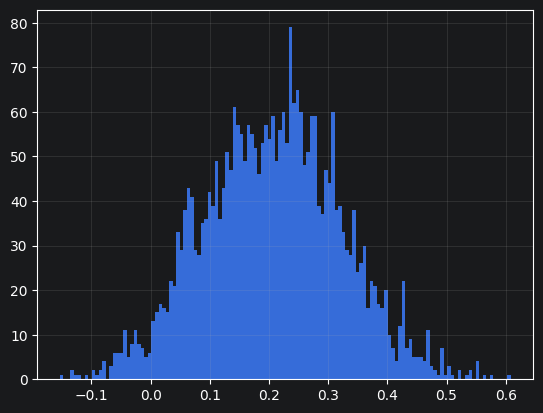

In [5]:
plt.hist(score_list, bins=128)
plt.grid(alpha=0.2)
grad_list = np.array(grad_list)
# print(grad_list)

In [6]:
grad_list = np.nan_to_num(grad_list, nan=0.0)

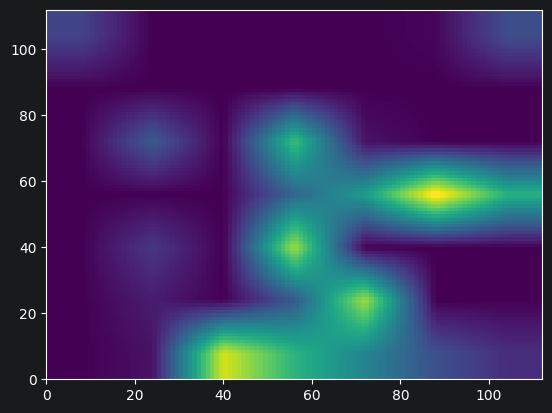

In [7]:
# print(grad_list)
plt.pcolormesh(grad_list[2, :, :])
plt.show()

In [8]:
step = .015
ranges = np.arange(-0.1, 0.5, step)
print(ranges)

[-0.1   -0.085 -0.07  -0.055 -0.04  -0.025 -0.01   0.005  0.02   0.035
  0.05   0.065  0.08   0.095  0.11   0.125  0.14   0.155  0.17   0.185
  0.2    0.215  0.23   0.245  0.26   0.275  0.29   0.305  0.32   0.335
  0.35   0.365  0.38   0.395  0.41   0.425  0.44   0.455  0.47   0.485]


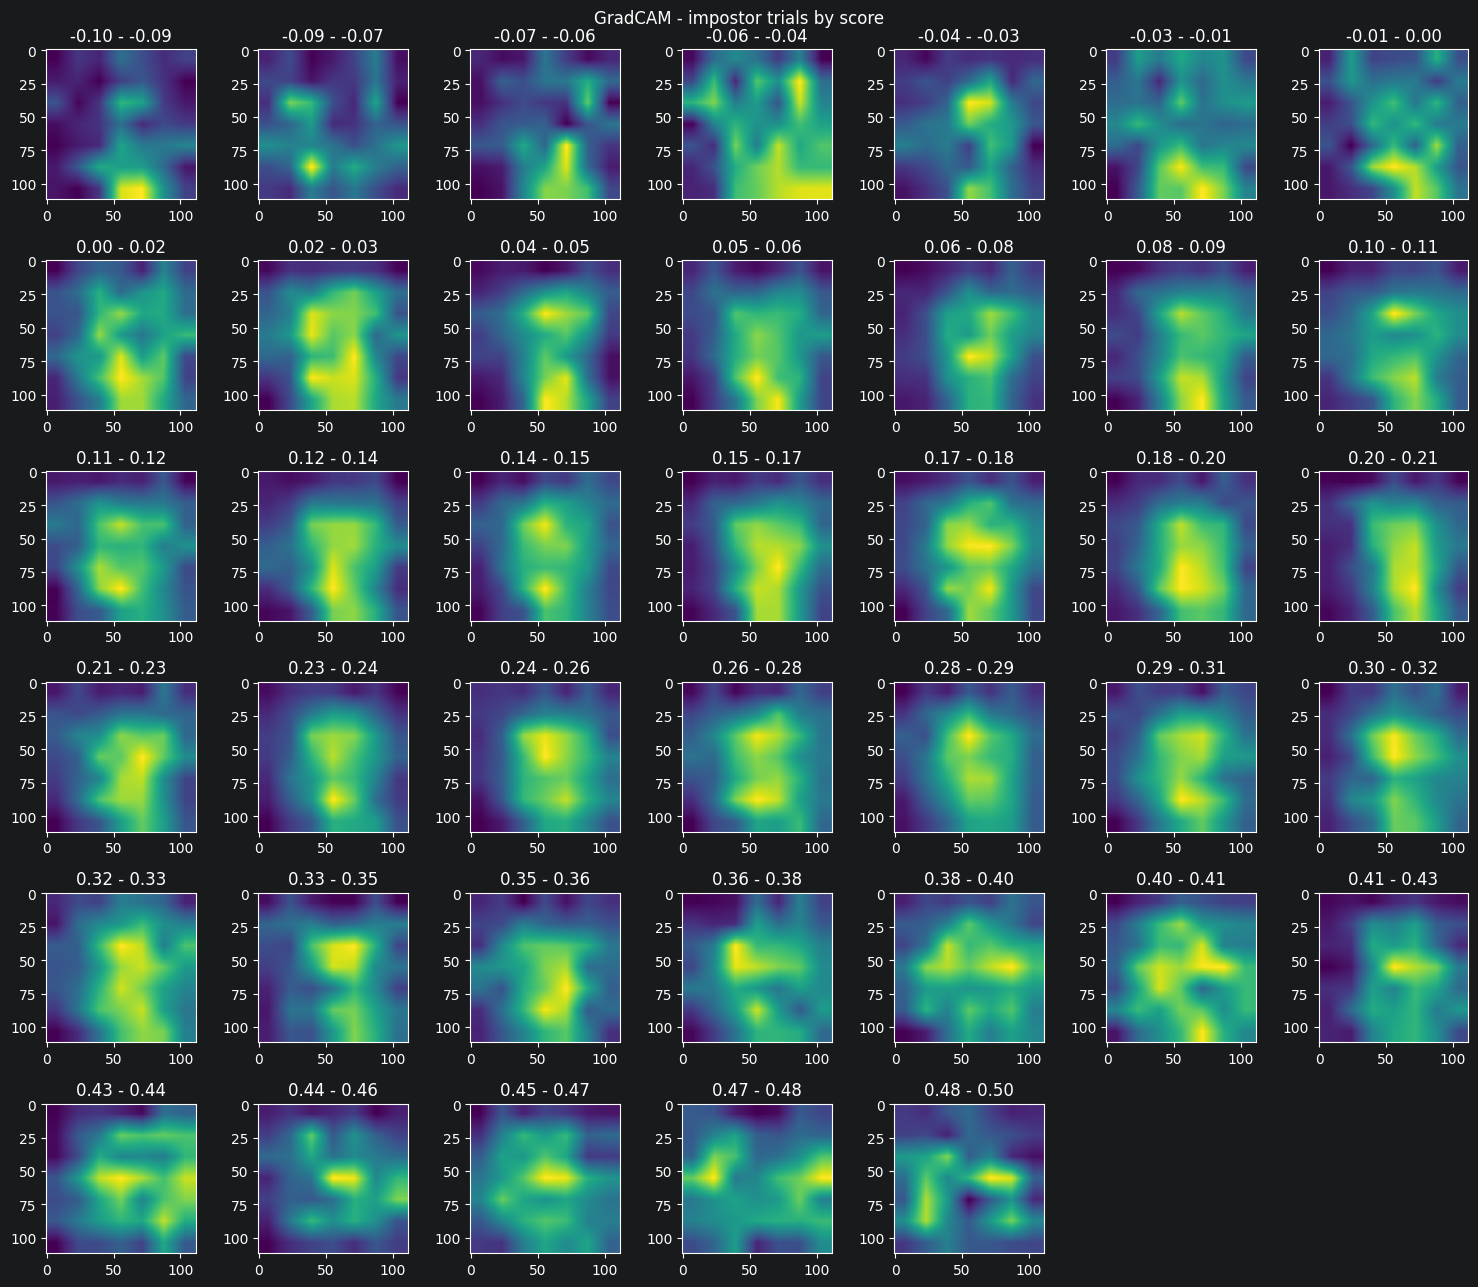

In [9]:
plt.figure(figsize=(15, 15))
for it, th in enumerate(ranges):
    idxs = np.where(np.logical_and(score_list >= th, score_list < th+step))[0]
    # print(idxs)
    th_scores = [score_list[idx] for idx in idxs]
    th_grads = np.array([grad_list[idx, :, :] for idx in idxs])
    # print(th_grads.shape)
    mean_th_grads = np.mean(th_grads, axis=0)
    # print(mean_th_grads.shape)
    # print(th_grads)

    try:
        plt.subplot(7, 7, it+1)
        plt.imshow(mean_th_grads)
        # plt.hist(mean_th_grads.flatten(), bins=256)
        plt.title(f"{th:.2f} - {th+step:.2f}")

    except:
        pass
plt.suptitle("GradCAM - impostor trials by score")
plt.tight_layout()
plt.savefig("insightface_layer_4_negative_trials.png")
plt.show()